In [1]:
import pandas as pd
import numpy as np
from uncertainties import unumpy as unp
from scipy.stats import ks_2samp, mannwhitneyu, anderson_ksamp, pearsonr
import statsmodels.api as sm

import matplotlib as mpl
from matplotlib import pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from matplotlib.ticker import (MultipleLocator, AutoMinorLocator)
from matplotlib.ticker import FormatStrFormatter
from matplotlib.ticker import LogLocator, ScalarFormatter, LogFormatter
import seaborn as sns

palette = 'viridis'
font = {'family': 'serif', 'color':  'black', 'weight': 'normal','size': 14}
font_cb = {'family': 'serif', 'color':  'black', 'weight': 'normal','size': 12}
labelsize=12

import warnings
warnings.filterwarnings('ignore')

In [98]:
data = pd.read_csv('Dados\data.csv', index_col='Cluster')
df = pd.read_csv(r'Dados\results.csv', index_col='Cluster')
benchmark_subsample = pd.read_csv(r'Dados\benchmark_subsample.csv', index_col='Cluster')

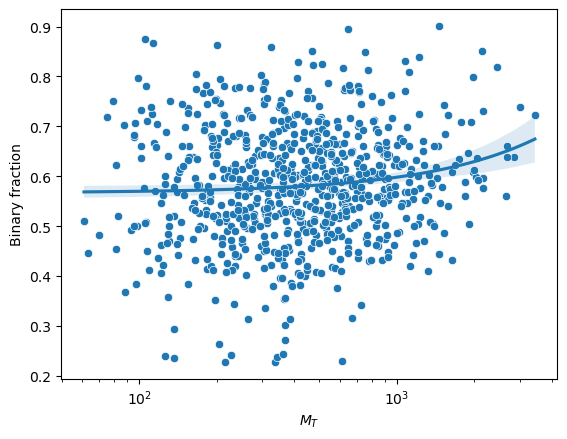

In [4]:
sns.regplot(data=df, x=df.mass_total, y='bin_frac', scatter=False, )
sns.scatterplot(data=df, x=df.mass_total, y='bin_frac')
plt.xscale('log')

plt.ylabel('Binary fraction')
plt.xlabel(r'$M_T$')
plt.show()


In [100]:
def calcula_sistemas(df, m, dm=1):
    ns = len(df[df.q==0])
    n_prim = len(df[(df.mass>m) & (df.mass<= m +dm) & (df.q>0)])
    n_sec = len(df[(df.comp_mass>m) & (df.comp_mass<= m +dm)])
    total = len(df[((df.mass>m) & (df.mass<= m +dm) )| ((df.comp_mass>m) & (df.comp_mass<= m +dm))])
    return ns, n_prim, n_sec, total

def calcula_P_prim(df, m, dm=1):
    total = len(df)
    N_prim = len(df[(df.mass>= m) & (df.mass<m+dm) & (df.comp_mass>0)])
    P_prim = N_prim/total
    q_prim = df[(df.mass>= m) & (df.mass<m+dm) & (df.comp_mass>0)].q.median()
    return P_prim, q_prim

def calcula_P_sec(df, m, dm=1):
    total = len(df)
    n_sec = len(df[(df.comp_mass>= m) & (df.comp_mass<m+dm) & (df.q>0)])
    P_sec = n_sec/total
    q_sec = df[(df.comp_mass>= m) & (df.comp_mass<m+dm) & (df.q>0)].q.median()
    return P_sec, q_sec

def calcula_P_BS(df,m, dm=1):
    n_prim = len(df[(df.mass>m) & (df.mass<= m +dm) & (df.q>0)])
    n_sec = len(df[(df.comp_mass>m) & (df.comp_mass<= m +dm)])
    total =len(df)
    P_BS = (n_prim+n_sec)/total
    q_BS = df[df.q>0].q.median()
    return P_BS, q_BS






def calcula_probabilidades(df, stat):
    m = 0
    x = []
    er_x = []
    P_prim_list = []
    P_sec_list = []
    P_BS_list = []
    n_stars = []
    qs = [[], [], []]  # [prim, sec, BS]
    min_mass = []
    max_mass = []

    while m < df.mass.max():
        
        if m<=1:
            dm = 0.1
        else:
            dm = 1
        mask = ((df.mass >= m) & (df.mass < m + dm)) | \
               ((df.comp_mass >= m) & (df.comp_mass < m + dm) & (df.q > 0))
        aux = df[mask]

        if len(aux) >= 100:
            primary_mass = aux[(aux.mass >= m) & (aux.mass < m + dm)][['mass', 'er_mass']]
            comp_mass = aux[(aux.comp_mass >= m) & (aux.comp_mass < m + dm)][['comp_mass', 'er_comp_mass']]

            pmemb = np.concatenate((
                aux[(aux.mass >= m) & (aux.mass < m + dm)]['Pmemb'],
                aux[(aux.comp_mass >= m) & (aux.comp_mass < m + dm)]['Pmemb']
            ))

            all_masses = np.concatenate((primary_mass.mass.values, comp_mass.comp_mass.values))
            er_all_masses = np.concatenate((primary_mass.er_mass.values, comp_mass.er_comp_mass.values))

            all_masses = unp.uarray(all_masses, er_all_masses)
            n_stars.append(len(all_masses))
            
            min_mass.append(m)
            max_mass.append((m+dm))

            # Estatísticas de massa
            if stat == 'media':
                mean = all_masses.mean()
                x.append(unp.nominal_values(mean))
                er_x.append(unp.std_devs(mean))
            elif stat == 'ponderada':
                pesos = pmemb * (1 / (unp.std_devs(all_masses) + 1e-10)**2)
                mean = (all_masses * pesos).sum() / pesos.sum()
                x.append(unp.nominal_values(mean))
                er_x.append(unp.std_devs(mean))

            # Probabilidades e razões de massa
            P_prim, q_prim = calcula_P_prim(aux, m, dm)
            P_sec, q_sec = calcula_P_sec(aux, m, dm)
            P_BS, q_BS = calcula_P_BS(aux, m, dm)

            P_prim_list.append(P_prim)
            P_sec_list.append(P_sec)
            P_BS_list.append(P_BS)

            qs[0].append(q_prim)
            qs[1].append(q_sec)
            qs[2].append(q_BS)

        m += dm

    return (
        np.array(min_mass),
        np.array(max_mass),
        np.array(x),
        np.array(er_x),
        np.array(P_prim_list),
        np.array(P_sec_list),
        np.array(P_BS_list),
        n_stars,
        qs
    )


In [101]:
samples = ['all', 'benchmark']
for sample in samples:
    if sample == 'benchmark':
        aux = data.loc[benchmark_subsample.index]
        color = 'orange'
        label = 'Benchmark subsample'
        
    else:
        aux = data
        
    min_mass, max_mass, mass, er_mass, P_prim, P_sec, P_BS, n_stars, qs = calcula_probabilidades(aux, 'media')
    
    if sample =='benchmark':
        results_benchmark = pd.DataFrame({
        'min_mass': min_mass,
        'max_mass': max_mass,
        'mean_mass': mass,
        'e_mean_mass': er_mass,
        'P_prim': P_prim,
        'P_comp': P_sec,
        'P_BS': P_BS,
        'n_stars': n_stars,
        'q_prim': qs[0],
        'q_comp': qs[1],
        'q_BS': qs[2]
        })
    else:
        results_all = pd.DataFrame({
        'min_mass': min_mass,
        'max_mass': max_mass,
        'mean_mass': mass,
        'e_mean_mass': er_mass,
        'P_prim': P_prim,
        'P_comp': P_sec,
        'P_BS': P_BS,
        'n_stars': n_stars,
        'q_prim': qs[0],
        'q_comp': qs[1],
        'q_BS': qs[2]
        })
    

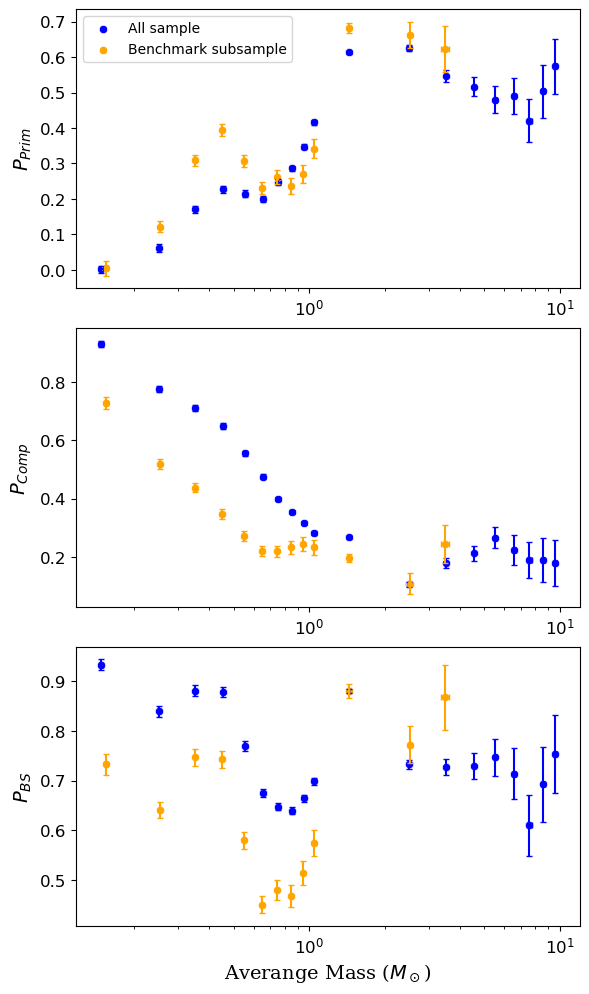

In [102]:
fig, axs = plt.subplots(3, 1, figsize=(6, 10), sharex=True)

for sample in samples:
    if sample == 'benchmark':
        data = results_benchmark
        color = 'orange'
        label = 'Benchmark subsample'
        
    else:
        data = results_all
        color = 'b'
        label = 'All sample'

    sns.scatterplot(data= data, x='mean_mass', y='P_prim', color=color, label=label, legend=True, ax=axs[0])
    sns.scatterplot(data= data, x='mean_mass', y='P_comp', color=color, legend=False, ax=axs[1])
    sns.scatterplot(data= data, x='mean_mass', y='P_BS', color=color, legend=False, ax=axs[2])

    err_y = np.sqrt(data.n_stars) / data.n_stars

    axs[0].errorbar(data.mean_mass, data.P_prim, xerr=data.e_mean_mass, yerr=err_y, fmt='none', ecolor=color, capsize=2)
    axs[1].errorbar(data.mean_mass, data.P_comp, xerr=data.e_mean_mass, yerr=err_y, fmt='none', ecolor=color, capsize=2)
    axs[2].errorbar(data.mean_mass, data.P_BS, xerr=data.e_mean_mass, yerr=err_y, fmt='none', ecolor=color, capsize=2)

    # Rótulos dos eixos
    axs[0].set_ylabel(r'$P_{Prim}$', fontdict=font)
    axs[1].set_ylabel(r'$P_{Comp}$', fontdict=font)
    axs[2].set_ylabel(r'$P_{BS}$', fontdict=font)
    axs[2].set_xlabel(r'Averange Mass ($M_\odot$)', fontdict=font)

for ax in axs:
    ax.tick_params(labelleft=True, labelbottom=True, labelsize=labelsize)

plt.tight_layout()
plt.xscale('log')
plt.savefig('Figures/dist_fb_por_massa.png', dpi=300)
plt.show()


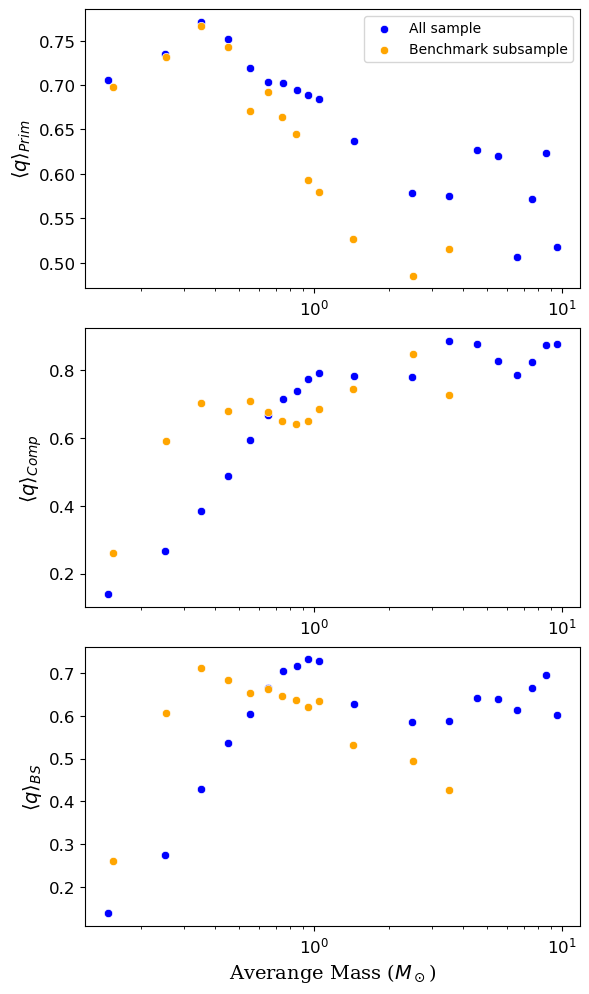

In [92]:
fig, axs = plt.subplots(3, 1, figsize=(6, 10), sharex=True)

for sample in samples:
    if sample == 'benchmark':
        data = results_benchmark
        color = 'orange'
        label = 'Benchmark subsample'
        
    else:
        data = results_all
        color = 'b'
        label = 'All sample'

    sns.scatterplot(data= data, x='mean_mass', y='q_prim', color=color, label=label, legend=True, ax=axs[0])
    sns.scatterplot(data= data, x='mean_mass', y='q_comp', color=color, legend=False, ax=axs[1])
    sns.scatterplot(data= data, x='mean_mass', y='q_BS', color=color, legend=False, ax=axs[2])

    #err_y = np.sqrt(data.n_stars) / data.n_stars

    #axs[0].errorbar(data.mean_mass, data.P_prim, xerr=data.e_mean_mass, yerr=err_y, fmt='none', ecolor=color, capsize=2)
    #axs[1].errorbar(data.mean_mass, data.P_comp, xerr=data.e_mean_mass, yerr=err_y, fmt='none', ecolor=color, capsize=2)
    #axs[2].errorbar(data.mean_mass, data.P_BS, xerr=data.e_mean_mass, yerr=err_y, fmt='none', ecolor=color, capsize=2)

    # Rótulos dos eixos
    axs[0].set_ylabel(r'$\langle q \rangle_{Prim}$', fontdict=font)
    axs[1].set_ylabel(r'$\langle q \rangle_{Comp}$', fontdict=font)
    axs[2].set_ylabel(r'$\langle q \rangle_{BS}$', fontdict=font)
    axs[2].set_xlabel(r'Averange Mass ($M_\odot$)', fontdict=font)

for ax in axs:
    ax.tick_params(labelleft=True, labelbottom=True, labelsize=labelsize)

plt.tight_layout()
plt.xscale('log')
plt.savefig('Figures/dist_q_por_massa.png', dpi=300)
plt.show()


# Low-mass

In [119]:
results_all[results_all.max_mass<=1][['P_prim', 'P_comp', 'P_BS','q_prim','q_comp', 'q_BS']].describe().round(2).T

,count,mean,std,min,25%,50%,75%,max
P_prim,9.0,0.20,0.11,0.00,0.17,0.21,0.25,0.35
P_comp,9.0,0.57,0.21,0.32,0.40,0.55,0.71,0.93
P_BS,9.0,0.77,0.12,0.64,0.66,0.77,0.88,0.93
q_prim,9.0,0.72,0.03,0.69,0.70,0.71,0.74,0.77
q_comp,9.0,0.53,0.23,0.14,0.38,0.59,0.71,0.77
q_BS,9.0,0.53,0.21,0.14,0.43,0.60,0.70,0.73


In [121]:
results_all[results_all.max_mass<=1][['mean_mass','P_prim', 'P_comp', 'P_BS','q_prim','q_comp', 'q_BS']].corr()

,mean_mass,P_prim,P_comp,P_BS,q_prim,q_comp,q_BS
mean_mass,1.000000,0.932166,-0.990016,-0.923644,-0.610345,0.973524,0.945876
P_prim,0.932166,1.000000,-0.931799,-0.755917,-0.314866,0.938737,0.946559
P_comp,-0.990016,-0.931799,1.000000,0.941991,0.549927,-0.989418,-0.971444
P_BS,-0.923644,-0.755917,0.941991,1.000000,0.700705,-0.916488,-0.876837
q_prim,-0.610345,-0.314866,0.549927,0.700705,1.000000,-0.510096,-0.415812
q_comp,0.973524,0.938737,-0.989418,-0.916488,-0.510096,1.000000,0.993210
q_BS,0.945876,0.946559,-0.971444,-0.876837,-0.415812,0.993210,1.000000


In [118]:
results_benchmark[results_benchmark.max_mass<=1][['P_prim', 'P_comp', 'P_BS','q_prim','q_comp', 'q_BS']].describe().round(2).T

,count,mean,std,min,25%,50%,75%,max
P_prim,9.0,0.24,0.11,0.01,0.23,0.26,0.31,0.39
P_comp,9.0,0.36,0.17,0.22,0.23,0.27,0.44,0.73
P_BS,9.0,0.60,0.12,0.45,0.48,0.58,0.73,0.75
q_prim,9.0,0.69,0.05,0.59,0.66,0.69,0.73,0.77
q_comp,9.0,0.62,0.14,0.26,0.64,0.65,0.68,0.71
q_BS,9.0,0.61,0.13,0.26,0.62,0.65,0.66,0.71


In [122]:
results_benchmark[results_benchmark.max_mass<=1][['mean_mass','P_prim', 'P_comp', 'P_BS','q_prim','q_comp', 'q_BS']].corr()

,mean_mass,P_prim,P_comp,P_BS,q_prim,q_comp,q_BS
mean_mass,1.000000,0.455437,-0.877384,-0.817716,-0.801780,0.525078,0.464917
P_prim,0.455437,1.000000,-0.706760,-0.076416,0.040440,0.869650,0.851963
P_comp,-0.877384,-0.706760,1.000000,0.759393,0.494650,-0.813605,-0.761252
P_BS,-0.817716,-0.076416,0.759393,1.000000,0.734346,-0.346883,-0.289364
q_prim,-0.801780,0.040440,0.494650,0.734346,1.000000,-0.015826,0.084006
q_comp,0.525078,0.869650,-0.813605,-0.346883,-0.015826,1.000000,0.987005
q_BS,0.464917,0.851963,-0.761252,-0.289364,0.084006,0.987005,1.000000


# Intermediate Mass

In [116]:
results_all[(results_all.max_mass>1)&(results_all.max_mass<=8) ][['P_prim', 'P_comp', 'P_BS','q_prim','q_comp', 'q_BS']].describe().round(2).T


,count,mean,std,min,25%,50%,75%,max
P_prim,7.0,0.53,0.07,0.42,0.48,0.52,0.58,0.63
P_comp,7.0,0.22,0.06,0.11,0.20,0.22,0.27,0.28
P_BS,7.0,0.75,0.06,0.70,0.72,0.73,0.74,0.88
q_prim,7.0,0.60,0.06,0.51,0.58,0.62,0.63,0.68
q_comp,7.0,0.82,0.05,0.78,0.78,0.79,0.85,0.89
q_BS,7.0,0.63,0.05,0.58,0.60,0.63,0.64,0.73


In [117]:
results_benchmark[(results_benchmark.max_mass>1)&(results_benchmark.max_mass<=8) ][['P_prim', 'P_comp', 'P_BS','q_prim','q_comp', 'q_BS']].describe().round(2).T


,count,mean,std,min,25%,50%,75%,max
P_prim,4.0,0.58,0.16,0.34,0.55,0.64,0.67,0.68
P_comp,4.0,0.20,0.06,0.11,0.18,0.22,0.24,0.24
P_BS,4.0,0.77,0.14,0.57,0.72,0.82,0.87,0.88
q_prim,4.0,0.53,0.04,0.49,0.51,0.52,0.54,0.58
q_comp,4.0,0.75,0.07,0.69,0.72,0.74,0.77,0.85
q_BS,4.0,0.52,0.09,0.43,0.48,0.51,0.56,0.64


In [126]:
results_all[(results_all.max_mass>1)&(results_all.max_mass<=8) ][['mean_mass','P_prim', 'P_comp', 
                                                                  'P_BS','q_prim','q_comp', 'q_BS']].corr()


,mean_mass,P_prim,P_comp,P_BS,q_prim,q_comp,q_BS
mean_mass,1.000000,-0.243092,-0.043916,-0.345195,-0.679488,0.275637,-0.359242
P_prim,-0.243092,1.000000,-0.621634,0.602738,-0.254445,-0.124056,-0.750391
P_comp,-0.043916,-0.621634,1.000000,0.250350,0.512998,-0.102530,0.729048
P_BS,-0.345195,0.602738,0.250350,1.000000,0.208091,-0.257776,-0.184806
q_prim,-0.679488,-0.254445,0.512998,0.208091,1.000000,0.021395,0.745702
q_comp,0.275637,-0.124056,-0.102530,-0.257776,0.021395,1.000000,-0.175622
q_BS,-0.359242,-0.750391,0.729048,-0.184806,0.745702,-0.175622,1.000000


In [127]:
results_all[(results_all.max_mass>=4)&(results_all.max_mass<=8) ][['mean_mass','P_prim', 'P_comp', 
                                                                  'P_BS','q_prim','q_comp', 'q_BS']].corr()


,mean_mass,P_prim,P_comp,P_BS,q_prim,q_comp,q_BS
mean_mass,1.000000,-0.897252,0.674042,-0.221117,-0.495689,-0.975079,0.369536
P_prim,-0.897252,1.000000,-0.929942,-0.226907,0.093259,0.836929,-0.636731
P_comp,0.674042,-0.929942,1.000000,0.569126,0.232223,-0.605684,0.722379
P_BS,-0.221117,-0.226907,0.569126,1.000000,0.823612,0.267279,0.489478
q_prim,-0.495689,0.093259,0.232223,0.823612,1.000000,0.622781,0.582663
q_comp,-0.975079,0.836929,-0.605684,0.267279,0.622781,1.000000,-0.173877
q_BS,0.369536,-0.636731,0.722379,0.489478,0.582663,-0.173877,1.000000


In [124]:
results_benchmark[(results_benchmark.max_mass>1)&(results_all.max_mass<=8) ][['mean_mass','P_prim', 'P_comp', 
                                                                  'P_BS','q_prim','q_comp', 'q_BS']].corr()


,mean_mass,P_prim,P_comp,P_BS,q_prim,q_comp,q_BS
mean_mass,1.000000,0.530816,-0.052898,0.575931,-0.680535,0.351468,-0.936211
P_prim,0.530816,1.000000,-0.471052,0.924526,-0.883503,0.653940,-0.781257
P_comp,-0.052898,-0.471052,1.000000,-0.099313,0.695369,-0.950563,0.135733
P_BS,0.575931,0.924526,-0.099313,1.000000,-0.696195,0.326978,-0.822650
q_prim,-0.680535,-0.883503,0.695369,-0.696195,1.000000,-0.878902,0.802332
q_comp,0.351468,0.653940,-0.950563,0.326978,-0.878902,1.000000,-0.434800
q_BS,-0.936211,-0.781257,0.135733,-0.822650,0.802332,-0.434800,1.000000


# High mass

In [128]:
results_all[(results_all.max_mass>8) ][['P_prim', 'P_comp', 'P_BS','q_prim','q_comp', 'q_BS']].describe().round(2).T


,count,mean,std,min,25%,50%,75%,max
P_prim,3.0,0.50,0.08,0.42,0.46,0.50,0.54,0.57
P_comp,3.0,0.19,0.01,0.18,0.18,0.19,0.19,0.19
P_BS,3.0,0.69,0.07,0.61,0.65,0.69,0.72,0.75
q_prim,3.0,0.57,0.05,0.52,0.54,0.57,0.60,0.62
q_comp,3.0,0.86,0.03,0.82,0.85,0.88,0.88,0.88
q_BS,3.0,0.65,0.05,0.60,0.63,0.66,0.68,0.70
